## Gisma University of Applied Sciences
### Department of Computer Science

## Evaluating AI-Driven Product Recommendation Systems Using Sentiment and Rating-Based Consumer Evaluation

### Name: Druv (GH1035710)

### Masters of Data Science, AI and Digital Business

Dataset Link: https://www.kaggle.com/datasets/fawadhossaini1415/amazon-fashion-800k-user-reviews-dataset

In [3]:
# 1. INSTALL REQUIRED PACKAGE

import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "sentence-transformers"
])


0

In [4]:
# 2. IMPORT LIBRARIES

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")


In [5]:
# 3. CONFIGURATION


FILE_PATH = "amazon_fashion.csv"

PRODUCT_ID_COLUMN = "parent_asin"

K_VALUES = [5, 10, 20]


MAX_EVALUATION_QUERIES = 1000

TRANSFORMER_MODEL = "all-MiniLM-L6-v2"

TFIDF_MAX_FEATURES = 10000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2

RELEVANCE_THRESHOLD = 4.0

SEED = 42

np.random.seed(SEED)


In [6]:
# 4. LOAD DATA

print("\nLoading dataset...")

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())



Loading dataset...
Dataset shape: (867310, 11)

Columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchases', 'target']


In [7]:
# 5. CHECK REQUIRED COLUMNS

required_columns = [
    "rating",
    "title",
    "text",
    "asin",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchases"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nAll required columns are available.")



All required columns are available.


In [8]:
# 6. SELECT VARIABLES

columns_to_keep = required_columns.copy()

if "target" in df.columns:
    columns_to_keep.append("target")

df = df[columns_to_keep].copy()


In [9]:
# 7. DATA CLEANING

print("\nCleaning data...")

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df["helpful_vote"] = pd.to_numeric(
    df["helpful_vote"],
    errors="coerce"
).fillna(0)

df["text"] = df["text"].fillna("").astype(str)

df["title"] = df["title"].fillna("").astype(str)

df["parent_asin"] = (
    df["parent_asin"]
    .fillna("")
    .astype(str)
)

df = df[
    (df["text"].str.strip() != "") &
    (df["parent_asin"].str.strip() != "") &
    (df["rating"].between(1, 5))
].copy()

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)



Cleaning data...
Cleaned dataset shape: (866537, 10)


In [10]:
# 8. TEXT PREPROCESSING

print("\nPreprocessing review text...")

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_text"] = df["text"].map(clean_text)

df = df[
    df["clean_text"].str.len() > 0
].copy()

df.reset_index(drop=True, inplace=True)

print("After text cleaning:", df.shape)




Preprocessing review text...
After text cleaning: (865852, 11)


In [13]:
# 9. RATING-DERIVED SENTIMENT

print("\nCreating rating-derived sentiment...")


df["rating_sentiment"] = np.select(
    [
        df["rating"] <= 2,
        df["rating"] == 3,
        df["rating"] >= 4
    ],
    [
        "Negative",
        "Neutral",
        "Positive"
    ],
    default="Unknown"
)

print(
    df["rating_sentiment"]
    .value_counts()
)




Creating rating-derived sentiment...
rating_sentiment
Negative    346514
Positive    346055
Neutral     173283
Name: count, dtype: int64


In [14]:
# 10. REVIEW CHARACTERISTICS

df["review_length"] = (
    df["clean_text"]
    .str.split()
    .str.len()
)

df["verified_purchase"] = (
    df["verified_purchases"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

print("\nReview characteristics:")
print(
    df[
        [
            "rating",
            "review_length",
            "helpful_vote"
        ]
    ].describe()
)



Review characteristics:
              rating  review_length   helpful_vote
count  865852.000000  865852.000000  865852.000000
mean        2.999151      30.979784       0.562865
std         1.413858      38.131753       3.454498
min         1.000000       1.000000       0.000000
25%         2.000000       9.000000       0.000000
50%         3.000000      20.000000       0.000000
75%         4.000000      39.000000       0.000000
max         5.000000    2306.000000     954.000000


In [15]:
# 11. BASIC DATA ANALYSIS

print("\nBasic dataset statistics")

print("Number of reviews:", len(df))

print(
    "Number of products:",
    df[PRODUCT_ID_COLUMN].nunique()
)

print(
    "Average rating:",
    round(df["rating"].mean(), 3)
)

print(
    "Verified purchase percentage:",
    round(
        df["verified_purchase"].mean() * 100,
        2
    ),
    "%"
)



Basic dataset statistics
Number of reviews: 865852
Number of products: 424283
Average rating: 2.999
Verified purchase percentage: 93.28 %


In [16]:
# 12. PRODUCT-LEVEL AGGREGATION

print("\nCreating product-level representations...")

product_data = (
    df.groupby(PRODUCT_ID_COLUMN)
    .agg(
        combined_text=("clean_text", " ".join),
        mean_rating=("rating", "mean"),
        review_count=("rating", "count"),
        mean_helpful_votes=("helpful_vote", "mean"),
        mean_review_length=("review_length", "mean")
    )
    .reset_index()
)

print(
    "Number of products:",
    len(product_data)
)




Creating product-level representations...
Number of products: 424283


In [17]:
# 13. RATING-BASED RELEVANCE

product_data["relevant"] = (
    product_data["mean_rating"]
    >= RELEVANCE_THRESHOLD
)

print("\nRating-based relevance:")

print(
    product_data["relevant"]
    .value_counts()
)

print(
    "Relevant products:",
    product_data["relevant"].sum()
)

print(
    "Non-relevant products:",
    (~product_data["relevant"]).sum()
)



Rating-based relevance:
relevant
False    283054
True     141229
Name: count, dtype: int64
Relevant products: 141229
Non-relevant products: 283054


In [18]:
# 14. TF-IDF REPRESENTATION

print("\nCreating TF-IDF representation...")

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    product_data["combined_text"]
)

print(
    "TF-IDF matrix shape:",
    tfidf_matrix.shape
)



Creating TF-IDF representation...
TF-IDF matrix shape: (424283, 10000)


In [19]:
# 15. TRANSFORMER REPRESENTATION

print("\nLoading transformer model...")

transformer_model = SentenceTransformer(
    TRANSFORMER_MODEL
)

print("Creating transformer embeddings...")

transformer_embeddings = transformer_model.encode(
    product_data["combined_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

transformer_embeddings = np.asarray(
    transformer_embeddings
)

print(
    "Transformer embedding shape:",
    transformer_embeddings.shape
)



Loading transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Creating transformer embeddings...


Batches:   0%|          | 0/6630 [00:00<?, ?it/s]

Transformer embedding shape: (424283, 384)


In [20]:
# 16. RECOMMENDATION FUNCTION

def get_top_recommendations(
    similarity_scores,
    query_index,
    k
):

    scores = similarity_scores.copy()

    scores[query_index] = -np.inf


    candidate_count = min(
        k,
        len(scores) - 1
    )

    top_indices = np.argpartition(
        -scores,
        candidate_count
    )[:candidate_count]

 
    top_indices = top_indices[
        np.argsort(
            -scores[top_indices]
        )
    ]

    return top_indices



In [21]:

# 17. EVALUATION FUNCTIONS

def precision_at_k(
    recommended_indices,
    relevant_items,
    k
):

    recommended = recommended_indices[:k]

    hits = sum(
        idx in relevant_items
        for idx in recommended
    )

    return hits / k


def recall_at_k(
    recommended_indices,
    relevant_items,
    k
):

    if len(relevant_items) == 0:
        return 0.0

    recommended = recommended_indices[:k]

    hits = sum(
        idx in relevant_items
        for idx in recommended
    )

    return hits / len(relevant_items)


def ndcg_at_k(
    recommended_indices,
    relevant_items,
    k
):

    recommended = recommended_indices[:k]

    dcg = 0.0

    for rank, idx in enumerate(
        recommended,
        start=1
    ):

        relevance = (
            1 if idx in relevant_items
            else 0
        )

        dcg += (
            relevance /
            np.log2(rank + 1)
        )

    # Ideal DCG
    ideal_hits = min(
        len(relevant_items),
        k
    )

    if ideal_hits == 0:
        return 0.0

    ideal_dcg = sum(
        1 / np.log2(rank + 1)
        for rank in range(
            1,
            ideal_hits + 1
        )
    )

    return dcg / ideal_dcg


def diversity_at_k(
    recommended_indices,
    embeddings,
    k
):

    recommended = recommended_indices[:k]

    if len(recommended) < 2:
        return 0.0

    selected_embeddings = embeddings[
        recommended
    ]

    similarity = cosine_similarity(
        selected_embeddings
    )

    upper_triangle = similarity[
        np.triu_indices(
            len(recommended),
            k=1
        )
    ]

    if len(upper_triangle) == 0:
        return 0.0

    return 1 - np.mean(
        upper_triangle
    )



In [22]:
# 18. SAMPLE EVALUATION QUERIES

print("\nSelecting evaluation queries...")

n_products = len(product_data)

query_count = min(
    MAX_EVALUATION_QUERIES,
    n_products
)

query_indices = np.random.choice(
    n_products,
    size=query_count,
    replace=False
)

query_indices = sorted(
    query_indices
)

print(
    "Evaluation queries:",
    len(query_indices)
)


Selecting evaluation queries...
Evaluation queries: 1000


In [23]:
# 19. GLOBAL RELEVANT PRODUCTS


relevant_indices = set(
    product_data.index[
        product_data["relevant"]
    ].tolist()
)

print(
    "Total relevant products:",
    len(relevant_indices)
)


Total relevant products: 141229


In [24]:
# 20. TF-IDF EVALUATION

print("\nEvaluating TF-IDF model...")

tfidf_results = []

for query_index in tqdm(
    query_indices,
    desc="TF-IDF"
):

    query_vector = tfidf_matrix[
        query_index
    ]

    scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    for k in K_VALUES:

        recommendations = (
            get_top_recommendations(
                scores,
                query_index,
                k
            )
        )

        precision = precision_at_k(
            recommendations,
            relevant_indices,
            k
        )

        recall = recall_at_k(
            recommendations,
            relevant_indices,
            k
        )

        ndcg = ndcg_at_k(
            recommendations,
            relevant_indices,
            k
        )

        diversity = diversity_at_k(
            recommendations,
            tfidf_matrix,
            k
        )

        tfidf_results.append({

            "query_index": query_index,

            "K": k,

            "precision": precision,

            "recall": recall,

            "ndcg": ndcg,

            "diversity": diversity

        })


tfidf_results = pd.DataFrame(
    tfidf_results
)



Evaluating TF-IDF model...


TF-IDF:   0%|          | 0/1000 [00:00<?, ?it/s]

In [25]:
# 21. TRANSFORMER EVALUATION

print("\nEvaluating Transformer model...")

transformer_results = []

for query_index in tqdm(
    query_indices,
    desc="Transformer"
):

    query_embedding = (
        transformer_embeddings[
            query_index
        ]
        .reshape(1, -1)
    )

    scores = cosine_similarity(
        query_embedding,
        transformer_embeddings
    ).flatten()

    for k in K_VALUES:

        recommendations = (
            get_top_recommendations(
                scores,
                query_index,
                k
            )
        )

        precision = precision_at_k(
            recommendations,
            relevant_indices,
            k
        )

        recall = recall_at_k(
            recommendations,
            relevant_indices,
            k
        )

        ndcg = ndcg_at_k(
            recommendations,
            relevant_indices,
            k
        )

        diversity = diversity_at_k(
            recommendations,
            transformer_embeddings,
            k
        )

        transformer_results.append({

            "query_index": query_index,

            "K": k,

            "precision": precision,

            "recall": recall,

            "ndcg": ndcg,

            "diversity": diversity

        })


transformer_results = pd.DataFrame(
    transformer_results
)



Evaluating Transformer model...


Transformer:   0%|          | 0/1000 [00:00<?, ?it/s]

In [26]:
# 22. CATALOGUE COVERAGE

print("\nCalculating catalogue coverage...")

def calculate_coverage(
    model_embeddings,
    query_indices,
    total_products
):

    recommended_products = set()

    for query_index in tqdm(
        query_indices,
        desc="Coverage"
    ):

        query_embedding = (
            model_embeddings[
                query_index
            ]
            .reshape(1, -1)
        )

        scores = cosine_similarity(
            query_embedding,
            model_embeddings
        ).flatten()

        recommendations = (
            get_top_recommendations(
                scores,
                query_index,
                max(K_VALUES)
            )
        )

        recommended_products.update(
            recommendations
        )

    return (
        len(recommended_products)
        / total_products
    )


tfidf_coverage = (
    len(
        set(
            idx
            for query_index in query_indices
            for idx in
            get_top_recommendations(
                cosine_similarity(
                    tfidf_matrix[
                        query_index
                    ],
                    tfidf_matrix
                ).flatten(),
                query_index,
                max(K_VALUES)
            )
        )
    )
    / n_products
)


transformer_recommended_products = set()

for query_index in tqdm(
    query_indices,
    desc="Transformer coverage"
):

    scores = cosine_similarity(
        transformer_embeddings[
            query_index
        ].reshape(1, -1),
        transformer_embeddings
    ).flatten()

    recommendations = (
        get_top_recommendations(
            scores,
            query_index,
            max(K_VALUES)
        )
    )

    transformer_recommended_products.update(
        recommendations
    )


transformer_coverage = (
    len(transformer_recommended_products)
    / n_products
)


Calculating catalogue coverage...


Transformer coverage:   0%|          | 0/1000 [00:00<?, ?it/s]

In [27]:
# 23. PERFORMANCE SUMMARY

tfidf_summary = (
    tfidf_results
    .groupby("K")
    [
        [
            "precision",
            "recall",
            "ndcg",
            "diversity"
        ]
    ]
    .mean()
    .reset_index()
)

tfidf_summary["model"] = "TF-IDF"


transformer_summary = (
    transformer_results
    .groupby("K")
    [
        [
            "precision",
            "recall",
            "ndcg",
            "diversity"
        ]
    ]
    .mean()
    .reset_index()
)

transformer_summary["model"] = (
    "Transformer"
)


performance_summary = pd.concat(
    [
        tfidf_summary,
        transformer_summary
    ],
    ignore_index=True
)

performance_summary = performance_summary[
    [
        "model",
        "K",
        "precision",
        "recall",
        "ndcg",
        "diversity"
    ]
]


print("PERFORMANCE SUMMARY")

print(
    performance_summary.round(4)
)


PERFORMANCE SUMMARY
         model   K  precision  recall    ndcg  diversity
0       TF-IDF   5     0.4010  0.0000  0.4011     0.4650
1       TF-IDF  10     0.4097  0.0000  0.4073     0.5156
2       TF-IDF  20     0.4069  0.0001  0.4061     0.5768
3  Transformer   5     0.3376  0.0000  0.3394     0.2857
4  Transformer  10     0.3382  0.0000  0.3393     0.3047
5  Transformer  20     0.3404  0.0000  0.3404     0.3236


In [28]:
# 24. COVERAGE SUMMARY

coverage_summary = pd.DataFrame({

    "Model": [
        "TF-IDF",
        "Transformer"
    ],

    "Catalogue_Coverage": [
        tfidf_coverage,
        transformer_coverage
    ]

})


print("CATALOGUE COVERAGE")

print(
    coverage_summary.round(4)
)



CATALOGUE COVERAGE
         Model  Catalogue_Coverage
0       TF-IDF              0.0414
1  Transformer              0.0448


In [29]:
# 25. WILCOXON STATISTICAL TEST

print("WILCOXON TESTS")

statistical_results = []

for k in K_VALUES:

    tfidf_k = (
        tfidf_results[
            tfidf_results["K"] == k
        ]
        .sort_values("query_index")
    )

    transformer_k = (
        transformer_results[
            transformer_results["K"] == k
        ]
        .sort_values("query_index")
    )

    for metric in [
        "precision",
        "recall",
        "ndcg",
        "diversity"
    ]:

        x = tfidf_k[
            metric
        ].values

        y = transformer_k[
            metric
        ].values

        try:

            statistic, p_value = (
                wilcoxon(
                    x,
                    y
                )
            )

        except ValueError:

            statistic = np.nan
            p_value = np.nan

        statistical_results.append({

            "K": k,

            "metric": metric,

            "wilcoxon_statistic": statistic,

            "p_value": p_value

        })


statistical_results = pd.DataFrame(
    statistical_results
)

print(
    statistical_results.round(5)
)



WILCOXON TESTS
     K     metric  wilcoxon_statistic  p_value
0    5  precision             83925.5      0.0
1    5     recall             85646.5      0.0
2    5       ndcg            116864.5      0.0
3    5  diversity             93904.0      0.0
4   10  precision            113463.5      0.0
5   10     recall            113225.0      0.0
6   10       ndcg            153836.5      0.0
7   10  diversity             64421.5      0.0
8   20  precision            136775.5      0.0
9   20     recall            137856.5      0.0
10  20       ndcg            172478.0      0.0
11  20  diversity             38491.5      0.0


In [30]:
# 26. CONSUMER / RATING ANALYSIS

print("RATING-DERIVED SENTIMENT")

sentiment_summary = (
    df["rating_sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

sentiment_summary["percentage"] = (
    sentiment_summary["count"]
    / len(df)
    * 100
)

print(
    sentiment_summary.round(2)
)



RATING-DERIVED SENTIMENT
  sentiment   count  percentage
0  Negative  346514       40.02
1  Positive  346055       39.97
2   Neutral  173283       20.01


In [31]:
# 27. REVIEW CHARACTERISTICS BY RATING

review_characteristics = (
    df.groupby("rating")
    .agg(

        review_count=("rating", "count"),

        average_review_length=(
            "review_length",
            "mean"
        ),

        average_helpful_votes=(
            "helpful_vote",
            "mean"
        ),

        verified_purchase_rate=(
            "verified_purchase",
            "mean"
        )

    )
    .reset_index()
)

review_characteristics[
    "verified_purchase_rate"
] *= 100

print("REVIEW CHARACTERISTICS BY RATING")

print(
    review_characteristics.round(2)
)



REVIEW CHARACTERISTICS BY RATING
   rating  review_count  average_review_length  average_helpful_votes  \
0     1.0        173182                  27.63                   0.61   
1     2.0        173332                  33.37                   0.51   
2     3.0        173283                  34.45                   0.51   
3     4.0        173149                  35.30                   0.63   
4     5.0        172906                  24.14                   0.55   

   verified_purchase_rate  
0                   93.71  
1                   93.77  
2                   93.08  
3                   92.04  
4                   93.80  


In [32]:
# 28. PRODUCT-LEVEL CONSUMER ANALYSIS

product_consumer_analysis = (
    product_data[
        [
            PRODUCT_ID_COLUMN,
            "mean_rating",
            "review_count",
            "mean_helpful_votes",
            "mean_review_length",
            "relevant"
        ]
    ]
    .copy()
)

print("\nProduct-level analysis:")
print(
    product_consumer_analysis.describe()
)




Product-level analysis:
         mean_rating   review_count  mean_helpful_votes  mean_review_length
count  424283.000000  424283.000000       424283.000000       424283.000000
mean        2.972562       2.040742            0.469221           31.515751
std         1.300529       7.977153            2.483928           35.612107
min         1.000000       1.000000            0.000000            1.000000
25%         2.000000       1.000000            0.000000           11.000000
50%         3.000000       1.000000            0.000000           22.000000
75%         4.000000       2.000000            0.333333           39.333333
max         5.000000    2047.000000          954.000000         2306.000000


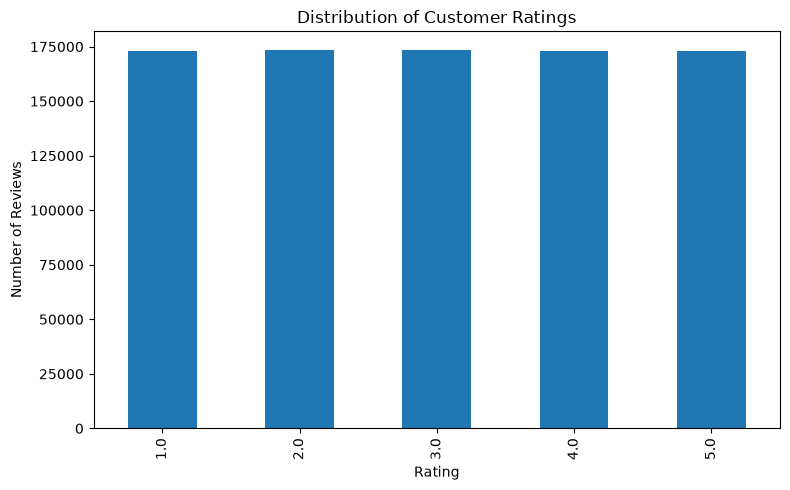

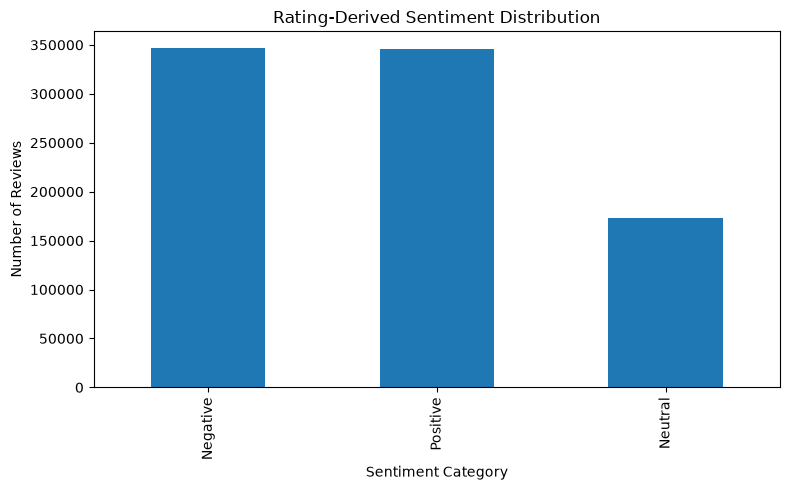

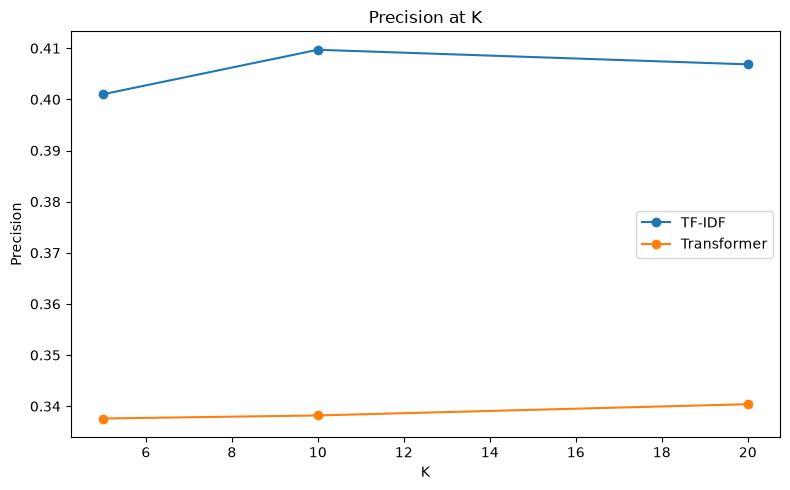

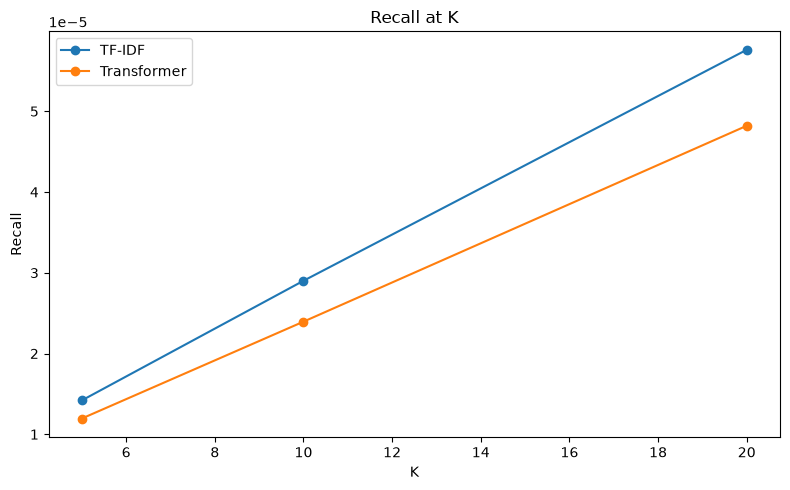

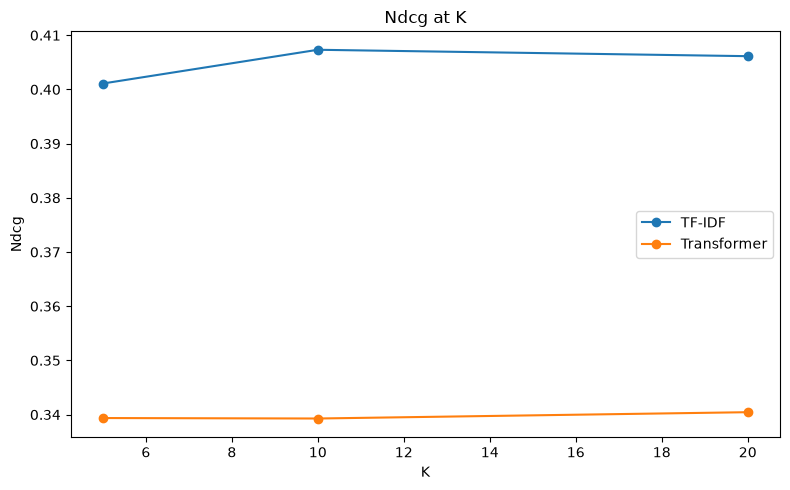

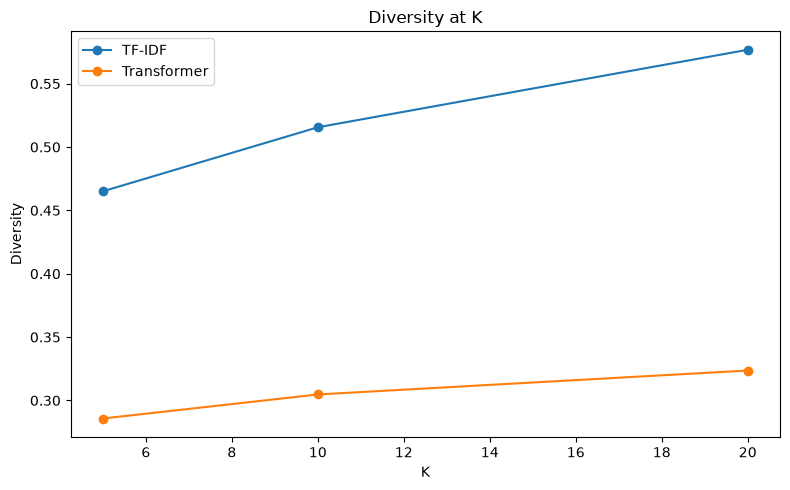

In [33]:
# 29. VISUALISATION 1 – RATING DISTRIBUTION

import matplotlib.pyplot as plt
from IPython.display import display

plt.figure(figsize=(8, 5))

df["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

# 30. VISUALISATION 2 – SENTIMENT DISTRIBUTION

plt.figure(figsize=(8, 5))

df["rating_sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Rating-Derived Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

# 31. VISUALISATION 3 – MODEL PERFORMANCE

for metric in [
    "precision",
    "recall",
    "ndcg",
    "diversity"
]:

    plt.figure(figsize=(8, 5))

    for model_name in [
        "TF-IDF",
        "Transformer"
    ]:

        subset = performance_summary[
            performance_summary["model"] == model_name
        ]

        plt.plot(
            subset["K"],
            subset[metric],
            marker="o",
            label=model_name
        )

    plt.title(f"{metric.capitalize()} at K")
    plt.xlabel("K")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.tight_layout()

    plt.show()



In [34]:
# 32. DISPLAY RESULTS

print("\n========== PERFORMANCE SUMMARY ==========")
display(performance_summary)

print("\n========== CATALOGUE COVERAGE ==========")
display(coverage_summary)

print("\n========== WILCOXON TEST RESULTS ==========")
display(statistical_results)

print("\n========== RATING SENTIMENT SUMMARY ==========")
display(sentiment_summary)

print("\n========== REVIEW CHARACTERISTICS ==========")
display(review_characteristics)

print("\n========== PRODUCT-CONSUMER ANALYSIS ==========")
display(product_consumer_analysis)


========== PERFORMANCE SUMMARY ==========


,model,K,precision,recall,ndcg,diversity
0,TF-IDF,5,0.40100,0.000014,0.401094,0.465047
1,TF-IDF,10,0.40970,0.000029,0.407321,0.515589
2,TF-IDF,20,0.40685,0.000058,0.406139,0.576752
3,Transformer,5,0.33760,0.000012,0.339365,0.285742
4,Transformer,10,0.33820,0.000024,0.339278,0.304713
5,Transformer,20,0.34040,0.000048,0.340443,0.323616



========== CATALOGUE COVERAGE ==========


,Model,Catalogue_Coverage
0,TF-IDF,0.041423
1,Transformer,0.044779



========== WILCOXON TEST RESULTS ==========


...

,sentiment,count,percentage
0,Negative,346514,40.020003
1,Positive,346055,39.966992
2,Neutral,173283,20.013005



========== REVIEW CHARACTERISTICS ==========


,rating,review_count,average_review_length,average_helpful_votes,verified_purchase_rate
0,1.0,173182,27.631561,0.612633,93.714127
1,2.0,173332,33.367174,0.511135,93.768606
2,3.0,173283,34.453235,0.509715,93.078375
3,4.0,173149,35.296681,0.633483,92.042114
4,5.0,172906,24.136091,0.547425,93.798364



========== PRODUCT-CONSUMER ANALYSIS ==========


,parent_asin,mean_rating,review_count,mean_helpful_votes,mean_review_length,relevant
0,0000099813,5.0,1,0.0,30.0,True
1,0310807115,5.0,1,0.0,24.0,True
2,0512239347,3.0,1,0.0,37.0,False
3,0512243085,3.0,1,0.0,36.0,False
4,0545142954,3.0,2,1.5,76.5,False
...,...,...,...,...,...,...
424278,B0CFTLY444,1.0,1,2.0,25.0,False
424279,B0CG7BKSN7,5.0,1,0.0,1.0,True
424280,B0CHMJXH2Z,1.0,1,1.0,63.0,False
424281,B0CHXMNLC9,1.0,1,0.0,40.0,False


In [35]:
# 33. EXPERIMENT CONFIGURATION

experiment_config = pd.DataFrame({

    "Parameter": [
        "Dataset",
        "Product ID",
        "TF-IDF",
        "TF-IDF max features",
        "TF-IDF n-grams",
        "TF-IDF minimum document frequency",
        "Transformer",
        "Relevance threshold",
        "Evaluation K values",
        "Evaluation queries",
        "Random seed"
    ],

    "Value": [
        FILE_PATH,
        PRODUCT_ID_COLUMN,
        "TF-IDF + Cosine Similarity",
        TFIDF_MAX_FEATURES,
        str(TFIDF_NGRAM_RANGE),
        TFIDF_MIN_DF,
        TRANSFORMER_MODEL,
        RELEVANCE_THRESHOLD,
        str(K_VALUES),
        MAX_EVALUATION_QUERIES,
        SEED
    ]
})

print("EXPERIMENT CONFIGURATION")

display(experiment_config)


EXPERIMENT CONFIGURATION


,Parameter,Value
0,Dataset,amazon_fashion.csv
1,Product ID,parent_asin
2,TF-IDF,TF-IDF + Cosine Similarity
3,TF-IDF max features,10000
4,TF-IDF n-grams,"(1, 2)"
5,TF-IDF minimum document frequency,2
6,Transformer,all-MiniLM-L6-v2
7,Relevance threshold,4.0
8,Evaluation K values,"[5, 10, 20]"
9,Evaluation queries,1000


In [36]:
# 34. SAMPLE RECOMMENDATIONS

print("SAMPLE RECOMMENDATIONS")

sample_query = query_indices[0]

print(
    "\nQuery product:",
    product_data.loc[
        sample_query,
        PRODUCT_ID_COLUMN
    ]
)


# ============================================================
# TF-IDF RECOMMENDATIONS
# ============================================================

tfidf_scores = cosine_similarity(
    tfidf_matrix[sample_query],
    tfidf_matrix
).flatten()

tfidf_recommendations = get_top_recommendations(
    tfidf_scores,
    sample_query,
    5
)

tfidf_results = []

for rank, idx in enumerate(
    tfidf_recommendations,
    start=1
):

    tfidf_results.append({
        "Rank": rank,
        "Product ID": product_data.loc[
            idx,
            PRODUCT_ID_COLUMN
        ],
        "Rating": round(
            product_data.loc[
                idx,
                "mean_rating"
            ],
            2
        )
    })

tfidf_results = pd.DataFrame(tfidf_results)

print("\nTF-IDF Recommendations")
display(tfidf_results)


# ============================================================
# TRANSFORMER RECOMMENDATIONS
# ============================================================

transformer_scores = cosine_similarity(
    transformer_embeddings[
        sample_query
    ].reshape(1, -1),
    transformer_embeddings
).flatten()

transformer_recommendations = get_top_recommendations(
    transformer_scores,
    sample_query,
    5
)

transformer_results = []

for rank, idx in enumerate(
    transformer_recommendations,
    start=1
):

    transformer_results.append({
        "Rank": rank,
        "Product ID": product_data.loc[
            idx,
            PRODUCT_ID_COLUMN
        ],
        "Rating": round(
            product_data.loc[
                idx,
                "mean_rating"
            ],
            2
        )
    })

transformer_results = pd.DataFrame(
    transformer_results
)

print("\nTransformer Recommendations")
display(transformer_results)


# ============================================================
# 35. FINAL EXPERIMENT RESULTS
# ============================================================

print("\n==========================================")
print("FINAL EXPERIMENT RESULTS")
print("==========================================")

print(
    "\nTF-IDF Catalogue Coverage:",
    round(tfidf_coverage, 4)
)

print(
    "Transformer Catalogue Coverage:",
    round(transformer_coverage, 4)
)


# ============================================================
# DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n==========================================")
print("PERFORMANCE SUMMARY")
print("==========================================")

display(performance_summary)


# ============================================================
# DISPLAY STATISTICAL RESULTS
# ============================================================

print("\n==========================================")
print("WILCOXON STATISTICAL RESULTS")
print("==========================================")

display(statistical_results)


# ============================================================
# DISPLAY COVERAGE RESULTS
# ============================================================

print("\n==========================================")
print("CATALOGUE COVERAGE")
print("==========================================")

display(coverage_summary)


print("\n==========================================")
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("==========================================")

print("All results and visualisations are displayed above.")
print("No files have been saved.")

SAMPLE RECOMMENDATIONS

Query product: 6152004349

TF-IDF Recommendations


,Rank,Product ID,Rating
0,1,B0C2VZD9ZM,5.0
1,2,B01537DQ2I,3.0
2,3,B016ID9JZE,3.0
3,4,B07116S5PQ,3.0
4,5,B07MQTQJ9T,5.0



Transformer Recommendations


,Rank,Product ID,Rating
0,1,B00AJHLNGY,4.00
1,2,B07G5FW3ZT,4.00
2,3,B01FQUQQ5Q,3.33
3,4,B07FM3DV7Y,3.00
4,5,B07Z2N2YNZ,4.50



FINAL EXPERIMENT RESULTS

TF-IDF Catalogue Coverage: 0.0414
Transformer Catalogue Coverage: 0.0448

PERFORMANCE SUMMARY


...


WILCOXON STATISTICAL RESULTS


,K,metric,wilcoxon_statistic,p_value
0,5,precision,83925.5,8.231179e-09
1,5,recall,85646.5,6.104874e-08
2,5,ndcg,116864.5,1.831580e-07
3,5,diversity,93904.0,8.606632e-65
4,10,precision,113463.5,3.265933e-12
5,10,recall,113225.0,2.542845e-12
6,10,ndcg,153836.5,1.997203e-10
7,10,diversity,64421.5,4.018735e-91
8,20,precision,136775.5,1.344445e-14
9,20,recall,137856.5,4.078310e-14



CATALOGUE COVERAGE


,Model,Catalogue_Coverage
0,TF-IDF,0.041423
1,Transformer,0.044779



EXPERIMENT COMPLETED SUCCESSFULLY
All results and visualisations are displayed above.
No files have been saved.


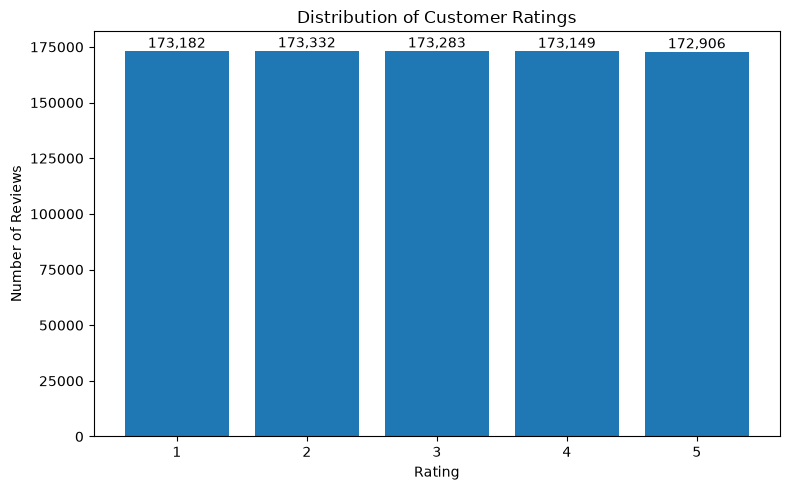

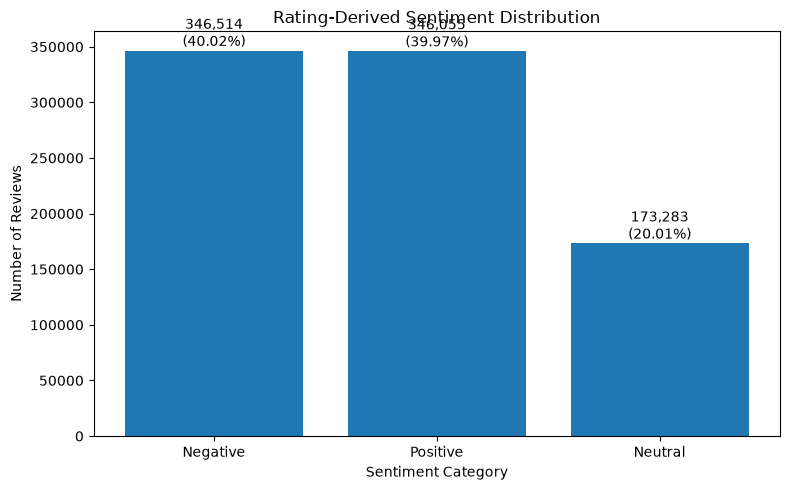

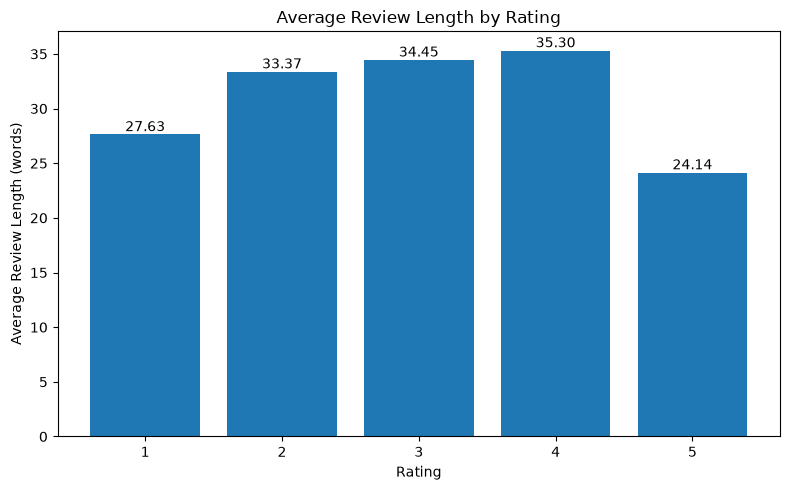

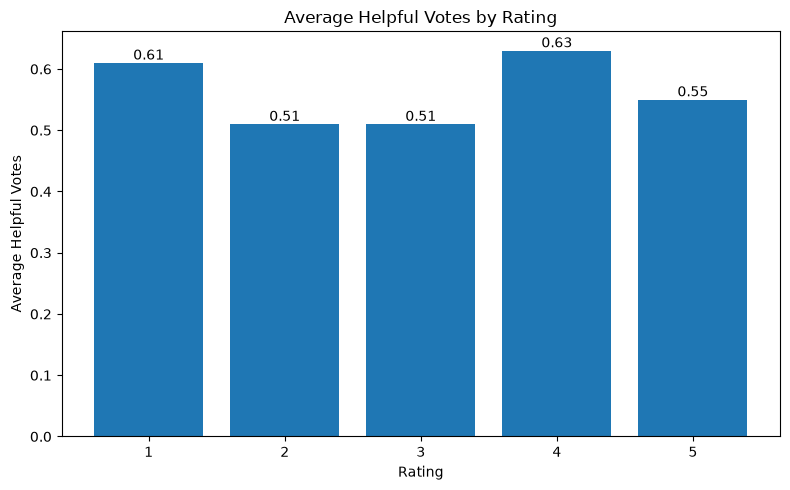

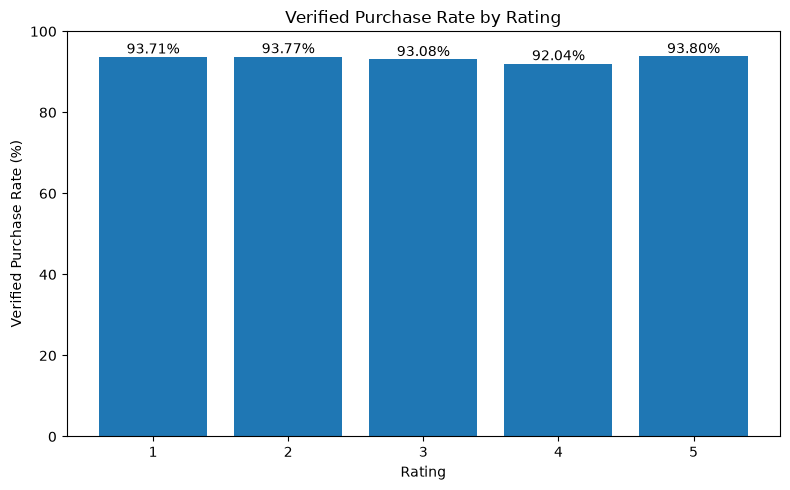

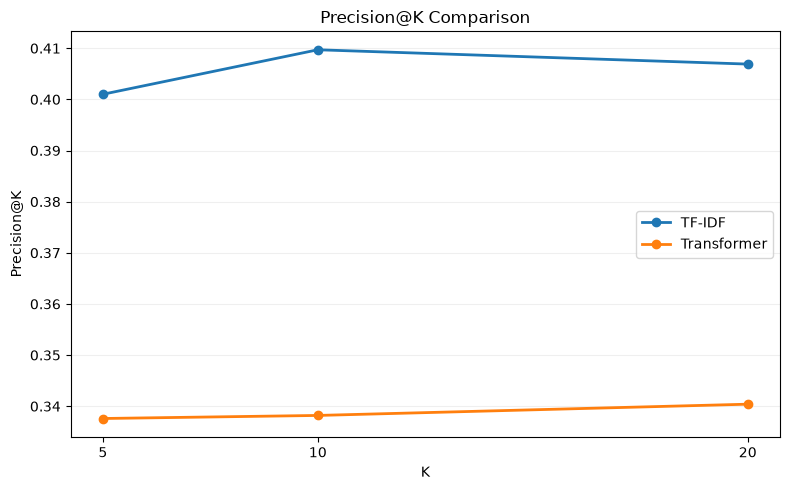

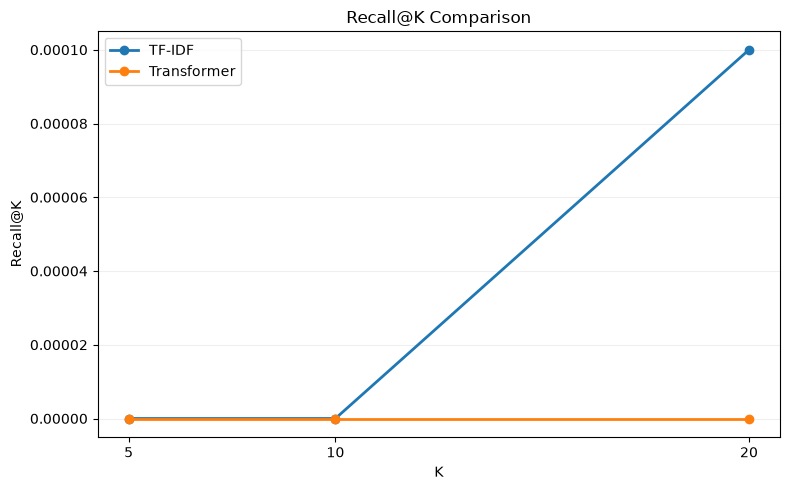

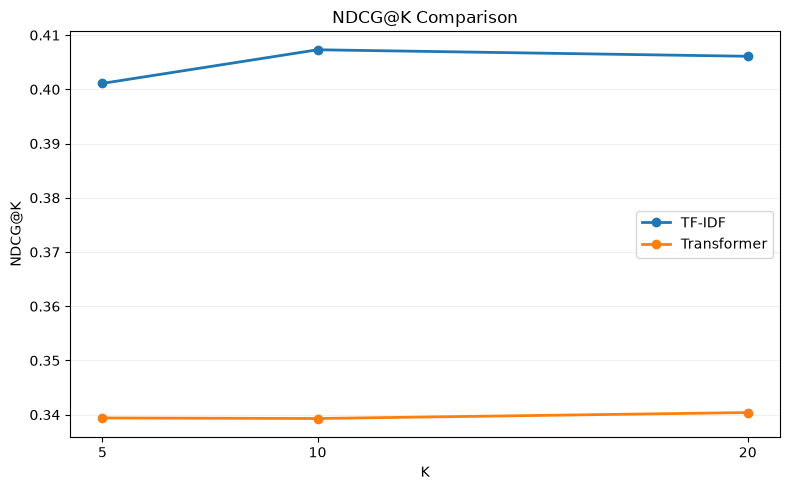

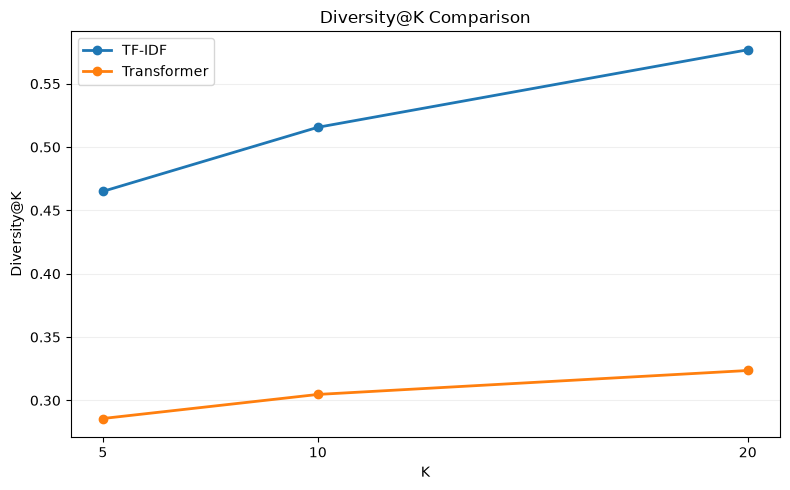

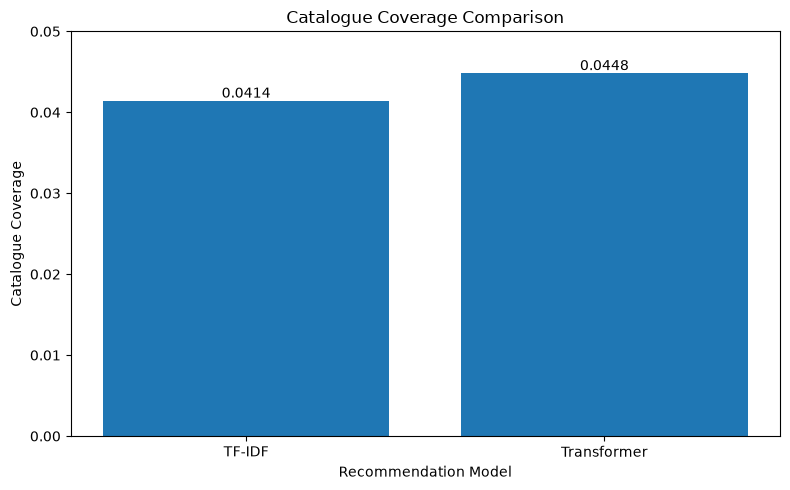

In [37]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. EDA — RATING DISTRIBUTION

ratings = [1, 2, 3, 4, 5]

rating_counts = [
    173182,
    173332,
    173283,
    173149,
    172906
]

plt.figure(figsize=(8, 5))

bars = plt.bar(ratings, rating_counts)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(ratings)

for bar, value in zip(bars, rating_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 2. EDA — RATING-DERIVED SENTIMENT

sentiments = [
    "Negative",
    "Positive",
    "Neutral"
]

sentiment_counts = [
    346514,
    346055,
    173283
]

sentiment_percentages = [
    40.02,
    39.97,
    20.01
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    sentiments,
    sentiment_counts
)

plt.title("Rating-Derived Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")

for bar, count, percentage in zip(
    bars,
    sentiment_counts,
    sentiment_percentages
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 3. EDA — REVIEW LENGTH BY RATING

rating_values = [1, 2, 3, 4, 5]

average_review_length = [
    27.63,
    33.37,
    34.45,
    35.30,
    24.14
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_values,
    average_review_length
)

plt.title(
    "Average Review Length by Rating"
)

plt.xlabel("Rating")
plt.ylabel("Average Review Length (words)")
plt.xticks(rating_values)

for bar, value in zip(
    bars,
    average_review_length
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 4. EDA — AVERAGE HELPFUL VOTES BY RATING

average_helpful_votes = [
    0.61,
    0.51,
    0.51,
    0.63,
    0.55
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_values,
    average_helpful_votes
)

plt.title(
    "Average Helpful Votes by Rating"
)

plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")
plt.xticks(rating_values)

for bar, value in zip(
    bars,
    average_helpful_votes
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 5. EDA — VERIFIED PURCHASE RATE

verified_rates = [
    93.71,
    93.77,
    93.08,
    92.04,
    93.80
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_values,
    verified_rates
)

plt.title(
    "Verified Purchase Rate by Rating"
)

plt.xlabel("Rating")
plt.ylabel("Verified Purchase Rate (%)")
plt.xticks(rating_values)

plt.ylim(0, 100)

for bar, value in zip(
    bars,
    verified_rates
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 6. RESULTS — PRECISION@K

K = [5, 10, 20]

tfidf_precision = [
    0.4010,
    0.4097,
    0.4069
]

transformer_precision = [
    0.3376,
    0.3382,
    0.3404
]

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    tfidf_precision,
    marker="o",
    linewidth=2,
    label="TF-IDF"
)

plt.plot(
    K,
    transformer_precision,
    marker="o",
    linewidth=2,
    label="Transformer"
)

plt.title("Precision@K Comparison")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.xticks(K)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


# 7. RESULTS — RECALL@K

tfidf_recall = [
    0.0000,
    0.0000,
    0.0001
]

transformer_recall = [
    0.0000,
    0.0000,
    0.0000
]

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    tfidf_recall,
    marker="o",
    linewidth=2,
    label="TF-IDF"
)

plt.plot(
    K,
    transformer_recall,
    marker="o",
    linewidth=2,
    label="Transformer"
)

plt.title("Recall@K Comparison")
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.xticks(K)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


# 8. RESULTS — NDCG@K

tfidf_ndcg = [
    0.4011,
    0.4073,
    0.4061
]

transformer_ndcg = [
    0.3394,
    0.3393,
    0.3404
]

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    tfidf_ndcg,
    marker="o",
    linewidth=2,
    label="TF-IDF"
)

plt.plot(
    K,
    transformer_ndcg,
    marker="o",
    linewidth=2,
    label="Transformer"
)

plt.title("NDCG@K Comparison")
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.xticks(K)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


# 9. RESULTS — DIVERSITY@K

tfidf_diversity = [
    0.4650,
    0.5156,
    0.5768
]

transformer_diversity = [
    0.2857,
    0.3047,
    0.3236
]

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    tfidf_diversity,
    marker="o",
    linewidth=2,
    label="TF-IDF"
)

plt.plot(
    K,
    transformer_diversity,
    marker="o",
    linewidth=2,
    label="Transformer"
)

plt.title("Diversity@K Comparison")
plt.xlabel("K")
plt.ylabel("Diversity@K")
plt.xticks(K)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


# 10. RESULTS — CATALOGUE COVERAGE

models = [
    "TF-IDF",
    "Transformer"
]

coverage = [
    0.0414,
    0.0448
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    models,
    coverage
)

plt.title(
    "Catalogue Coverage Comparison"
)

plt.xlabel("Recommendation Model")
plt.ylabel("Catalogue Coverage")

plt.ylim(
    0,
    0.05
)

for bar, value in zip(
    bars,
    coverage
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()